In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import fsolve

In [2]:
# Parameters

asset = "MSFT"  # Microsoft
ticker = yf.Ticker(asset)                          
S0 = ticker.history(period="1d")["Close"].iloc[-1]  # Spot price in $
sigma0 = 0.6    # volatility
r= 0.03         # interest rate
q = 0           # dividend yield
print(S0)

497.92999267578125


In [3]:
expiries = ticker.options  # available maturity for the options
expiries
expiries = list(expiries)
expiries

['2026-09-25',
 '2026-09-28',
 '2026-09-30',
 '2026-10-02',
 '2026-10-05',
 '2026-10-09',
 '2026-10-16',
 '2026-10-23',
 '2026-10-30',
 '2026-11-20',
 '2026-12-18',
 '2027-01-15',
 '2027-03-19',
 '2027-04-16',
 '2027-06-17',
 '2027-09-17',
 '2027-12-17',
 '2028-01-21',
 '2028-06-16',
 '2028-12-15',
 '2029-01-19']

In [4]:
# For each maturity date, we add a price, strike for a call option and put option

L_call = []
L_put = []

for maturity in expiries:

    option_chain = ticker.option_chain(date=maturity)

    call = option_chain.calls
    call["Maturity"] = maturity
    L_call.append(call)

    put = option_chain.puts
    put["Maturity"] = maturity
    L_put.append(put)

df_call= pd.concat(L_call)
df_put = pd.concat(L_put)
df_call


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,Maturity
0,MSFT260925C00280000,2026-09-22 18:59:30+00:00,280.0,218.80,0.0,0.0,0.0,0.0,NaN,0,0.000010,True,REGULAR,USD,2026-09-25
1,MSFT260925C00300000,2026-09-24 17:56:29+00:00,300.0,196.00,0.0,0.0,0.0,0.0,6.0,0,0.000010,True,REGULAR,USD,2026-09-25
2,MSFT260925C00305000,2026-09-24 17:56:29+00:00,305.0,191.00,0.0,0.0,0.0,0.0,6.0,0,0.000010,True,REGULAR,USD,2026-09-25
3,MSFT260925C00310000,2026-09-24 18:08:15+00:00,310.0,185.90,0.0,0.0,0.0,0.0,6.0,10,0.000010,True,REGULAR,USD,2026-09-25
4,MSFT260925C00315000,2026-09-24 18:11:19+00:00,315.0,181.15,0.0,0.0,0.0,0.0,7.0,0,0.000010,True,REGULAR,USD,2026-09-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,MSFT290119C00710000,2026-09-23 18:37:36+00:00,710.0,54.15,0.0,0.0,0.0,0.0,50.0,0,0.031260,False,REGULAR,USD,2029-01-19
59,MSFT290119C00720000,2026-09-23 18:38:06+00:00,720.0,52.02,0.0,0.0,0.0,0.0,91.0,0,0.062509,False,REGULAR,USD,2029-01-19
60,MSFT290119C00730000,2026-09-24 17:51:56+00:00,730.0,48.25,0.0,0.0,0.0,0.0,6.0,0,0.062509,False,REGULAR,USD,2029-01-19
61,MSFT290119C00740000,2026-09-23 17:44:30+00:00,740.0,48.20,0.0,0.0,0.0,0.0,95.0,0,0.062509,False,REGULAR,USD,2029-01-19


In [5]:
# Building the dataframes and first cleaning

columns = ["strike",'Maturity',"lastPrice","bid","ask","impliedVolatility","volume"]



df_call = df_call[columns]

df_call["mid"] = 0.5 * (df_call["bid"] + df_call["ask"])

df_call["Maturity"] = pd.to_datetime(df_call["Maturity"])

# filter

# Strike between 80% et 120%
strike_filter = (S0*0.8< df_call["strike"]) & (df_call["strike"]<S0*1.2)
df_call = df_call[strike_filter]

# maturity between today and 3 months 
maturity_filter = (df_call["Maturity"]>pd.Timestamp.today()) & (df_call["Maturity"] < pd.Timestamp.today() + pd.Timedelta(days=100))
df_call = df_call[maturity_filter]

# volume > 50
df_call = df_call[df_call["volume"]>50]

#mid price
# mid_filter = (df_call["mid"] >= 0.10)
# df_call = df_call[mid_filter]

df_call

# Put filter

df_put = df_put[columns]
df_put["mid"] = 0.5 * (df_put["bid"] + df_put["ask"])
df_put["Maturity"] = pd.to_datetime(df_put["Maturity"])



strike_filter = (S0*0.8< df_put["strike"]) & (df_put["strike"]<S0*1.2)
df_put = df_put[strike_filter]

maturity_filter = (df_put["Maturity"]>pd.Timestamp.today()) & (df_put["Maturity"] < pd.Timestamp.today() + pd.Timedelta(days=100))
df_put = df_put[maturity_filter]

# volume > 50
df_put = df_put[df_put["volume"]>50]

# mid price
mid_filter = (df_put["mid"] >= 0.10)
df_put = df_put[mid_filter]

df_call


C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\31573668.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_call["mid"] = 0.5 * (df_call["bid"] + df_call["ask"])
C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\31573668.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_call["Maturity"] = pd.to_datetime(df_call["Maturity"])


,strike,Maturity,lastPrice,bid,ask,impliedVolatility,volume,mid
8,470.0,2026-09-28,26.70,0.0,0.0,0.000010,75.0,0.0
9,472.5,2026-09-28,24.32,0.0,0.0,0.000010,70.0,0.0
10,475.0,2026-09-28,22.08,0.0,0.0,0.000010,75.0,0.0
11,477.5,2026-09-28,19.70,0.0,0.0,0.000010,66.0,0.0
15,487.5,2026-09-28,11.37,0.0,0.0,0.000010,160.0,0.0
...,...,...,...,...,...,...,...,...
80,575.0,2026-12-18,6.75,0.0,0.0,0.062509,189.0,0.0
81,580.0,2026-12-18,6.00,0.0,0.0,0.062509,97.0,0.0
82,585.0,2026-12-18,5.35,0.0,0.0,0.062509,51.0,0.0
83,590.0,2026-12-18,4.66,0.0,0.0,0.062509,80.0,0.0


In [6]:
# Price Call/Put with Black and Scholes
def black_scholes(S0,K,r,sigma,T,q,option_type="call"):

    d1= (np.log(S0/K)+(0.5*sigma**2*+r-q)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        return S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2) 
    
    if option_type == "put":
        return K*np.exp(-r*T)*norm.cdf(-d2)-S0*norm.cdf(-d1) 

In [7]:
option_type = "call"

In [8]:
# Function to get the determine the implied volatility
def implied_volatility(S0,K,T,r,q,market_price):
    def f(sigma):
        return black_scholes(S0,K,r,sigma,T,q,option_type)-market_price
    return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)  

In [9]:
# For a given maturity date, we want to know the value of the implied volatility for each strike

smile = {}

for t in df_call["Maturity"].drop_duplicates():
    time_to_maturity = (t - pd.Timestamp.today()).days / 365
    L_implied_vol=[]
    L_K = []

    df_t = df_call[df_call["Maturity"]==t]

    for _,row in df_t.iterrows():
        K = row["strike"]
        market_price = row["lastPrice"]     # or  row["mid"] 

        implied_vol = float(implied_volatility(S0,K,time_to_maturity,r,q,market_price)[0])
        L_implied_vol.append(implied_vol)
        L_K.append(K)
    
    smile[t] = {"K":L_K,
                "iv":L_implied_vol}
        

C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)


In [10]:
smile

{Timestamp('2026-09-28 00:00:00'): {'K': [470.0,
   472.5,
   475.0,
   477.5,
   487.5,
   490.0,
   492.5,
   495.0,
   497.5,
   500.0,
   502.5,
   505.0,
   507.5,
   510.0,
   512.5,
   515.0,
   517.5,
   520.0,
   522.5,
   525.0,
   535.0,
   542.5,
   545.0],
  'iv': [0.016505324849084818,
   0.06976345987041085,
   0.054875758097452765,
   0.06602990675704244,
   0.28645961917426616,
   0.32816989182325,
   0.293678538635076,
   0.29320019419744364,
   0.28985855129322197,
   0.2933502825869234,
   0.282014442852037,
   0.29048364179106556,
   0.29539978704854186,
   0.3009252796170091,
   0.2937396136666793,
   0.3078287151447394,
   0.31337054069856124,
   0.31936957089994095,
   0.3361940857805883,
   0.34359543267246684,
   0.38774757663014053,
   0.4342318068204668,
   0.4549899756573666]},
 Timestamp('2026-09-30 00:00:00'): {'K': [482.5,
   490.0,
   492.5,
   495.0,
   497.5,
   500.0,
   502.5,
   505.0,
   507.5,
   510.0,
   512.5,
   515.0,
   517.5,
   520.0,
   

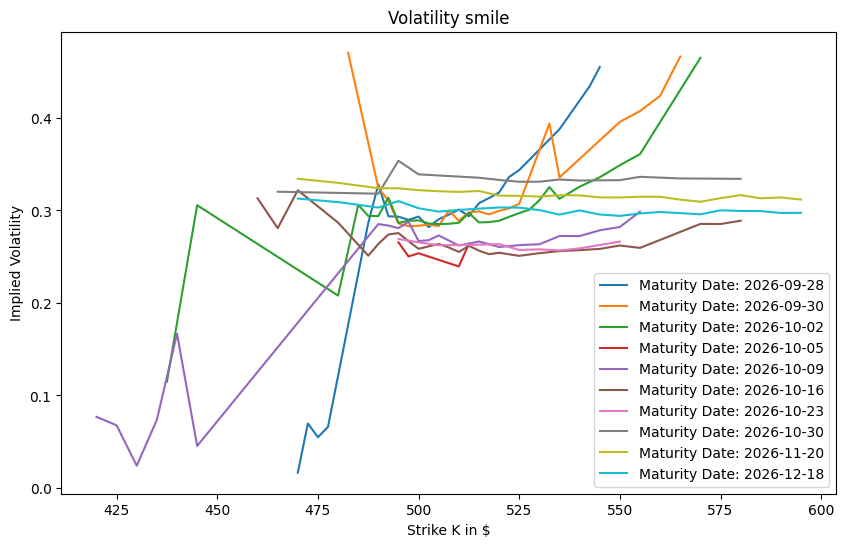

In [11]:
plt.figure(figsize=(10,6))
for t, data in smile.items():  # smile.items() renvoie couples (clé,valeur)
    plt.plot(data["K"],data["iv"],label="Maturity Date: " + str(t.date()))

plt.xlabel("Strike K in $")
plt.ylabel("Implied Volatility")
plt.title('Volatility smile')
plt.legend()
plt.show()

In [12]:
# For a given strike, we want to know the value of the implied volatility for each maturity

term_structure = {}
df_call = df_call.sort_values(by="strike",ascending=True)
for K in df_call["strike"].drop_duplicates():
    L_implied_vol=[]
    L_T = []

    df_K = df_call[df_call["strike"]==K]

    for _,row in df_K.iterrows():
        T = row["Maturity"]
        time_to_maturity = (T - pd.Timestamp.today()).days / 365
        market_price = row["lastPrice"]  # or row["mid"]

        implied_vol = float(implied_volatility(S0,K,time_to_maturity,r,q,market_price)[0])  # [0]
        
        L_implied_vol.append(implied_vol)
        #implied_vol = row["impliedVolatility"]
        L_T.append(T)
    
    term_structure[K] = {"T":L_T,
                "iv":L_implied_vol}
print(term_structure)

{420.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.0769043270603299]}, 425.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.06768219779406272]}, 430.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.024066364975114773]}, 435.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.07383480552123176]}, 437.5: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.11492926938860226]}, 440.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.16685315887779634]}, 445.0: {'T': [Timestamp('2026-10-09 00:00:00'), Timestamp('2026-10-02 00:00:00')], 'iv': [0.04544928692567765, 0.3056188356330752]}, 460.0: {'T': [Timestamp('2026-10-16 00:00:00')], 'iv': [0.3131201306152455]}, 465.0: {'T': [Timestamp('2026-10-16 00:00:00'), Timestamp('2026-10-30 00:00:00')], 'iv': [0.28082243735365686, 0.32021425648909296]}, 470.0: {'T': [Timestamp('2026-09-28 00:00:00'), Timestamp('2026-11-20 00:00:00'), Timestamp('2026-12-18 00:00:00'), Timestamp('2026-10-16 00:00:00')], 'iv': [0.016505324849084818, 

C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_4464\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_4464

In [13]:
term_structure

{420.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.0769043270603299]},
 425.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.06768219779406272]},
 430.0: {'T': [Timestamp('2026-10-09 00:00:00')],
  'iv': [0.024066364975114773]},
 435.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.07383480552123176]},
 437.5: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.11492926938860226]},
 440.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.16685315887779634]},
 445.0: {'T': [Timestamp('2026-10-09 00:00:00'),
   Timestamp('2026-10-02 00:00:00')],
  'iv': [0.04544928692567765, 0.3056188356330752]},
 460.0: {'T': [Timestamp('2026-10-16 00:00:00')], 'iv': [0.3131201306152455]},
 465.0: {'T': [Timestamp('2026-10-16 00:00:00'),
   Timestamp('2026-10-30 00:00:00')],
  'iv': [0.28082243735365686, 0.32021425648909296]},
 470.0: {'T': [Timestamp('2026-09-28 00:00:00'),
   Timestamp('2026-11-20 00:00:00'),
   Timestamp('2026-12-18 00:00:00'),
   Timestamp('2026-10-16 00:00:00')],

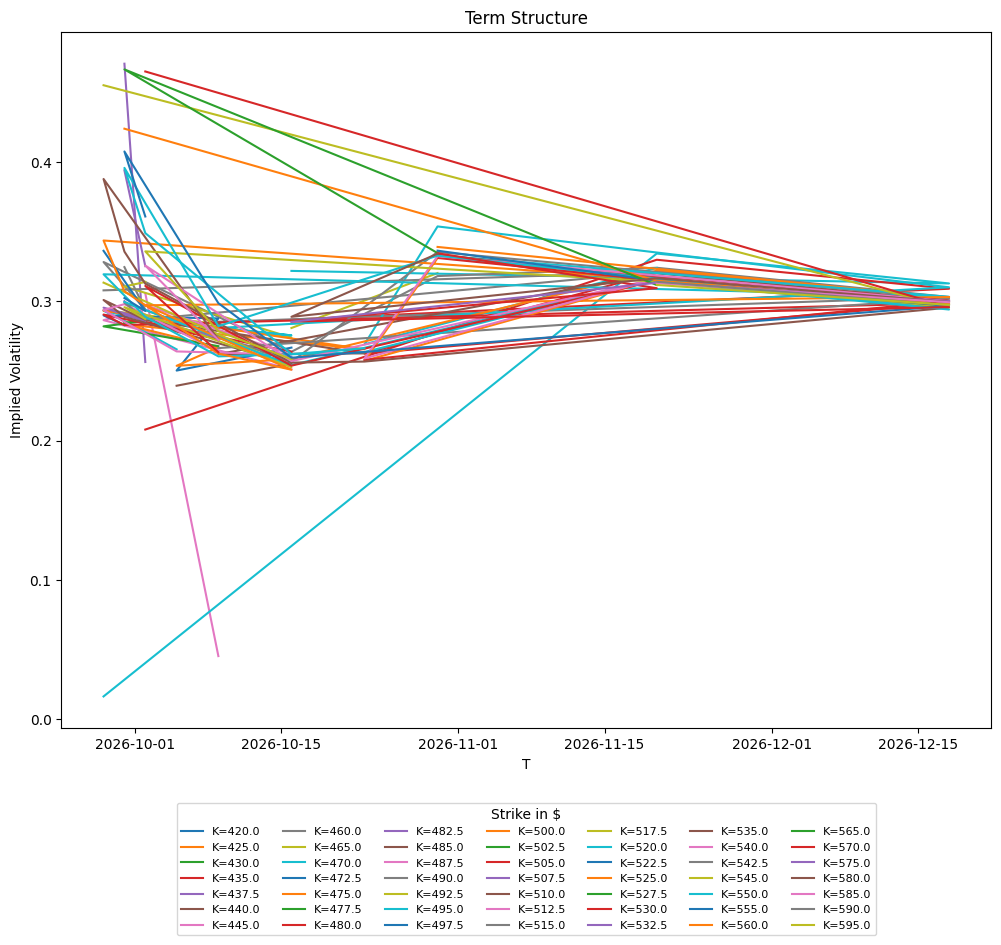

In [14]:
plt.figure(figsize=(12,12))
Ks_to_plot = np.arange(360,450,10) #[360.0, 370 ,380.0,390,400,410]
for K, data in term_structure.items():  # term_structure.items() renvoie couples (clé,valeur)
    plt.plot(data["T"],data["iv"],label=f"K={K}")

plt.xlabel("T")
plt.ylabel("Implied Volatility")
plt.title('Term Structure')

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=7,           
    title="Strike in $",
    fontsize=8,
    frameon=True
)

plt.subplots_adjust(bottom=0.30)

plt.show()

Volatility Surface

In [ ]:
from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D


# Transforming smile into threee vectors: strike K, maturity T, implied volatility IV

valuation_date = pd.Timestamp.today().normalize() # putting hour at midnight

K_obs = []
T_obs = []
IV_obs = []

for maturity, values in smile.items():

    # Converting maturity date in years
    T = (pd.Timestamp(maturity) - valuation_date).total_seconds() / (365 * 24 * 3600)

    # Removing options that are out of time of maturity
    if T <= 0:
        continue

    for K, iv in zip(values["K"], values["iv"]):

        # GKeeping appropriate values of volatility
        if np.isfinite(iv) and 0.01 < iv < 1.50:
            K_obs.append(float(K))
            T_obs.append(float(T))
            IV_obs.append(float(iv))

K_obs = np.array(K_obs)
T_obs = np.array(T_obs)
IV_obs = np.array(IV_obs)

print("Number of points :", len(IV_obs))
print("Number of maturity dates :", len(np.unique(T_obs)))
print("Number of strikes :", len(np.unique(K_obs)))

Number of points : 203
Number of maturity dates : 10
Number of strikes : 49


In [ ]:
# Creating a uniform grid (K, T)


K_grid = np.linspace(K_obs.min(), K_obs.max(), 80) # 80 positions of strike
T_grid = np.linspace(T_obs.min(), T_obs.max(), 80) # 80 positions of maturity

K_mesh, T_mesh = np.meshgrid(K_grid, T_grid) # 80*80 = 6400 couples of (K,T)

# linar interpolation with data from smile 
IV_mesh = griddata(
    points=(K_obs, T_obs),
    values=IV_obs,
    xi=(K_mesh, T_mesh),
    method="linear"
)

# griddata(linear) leves NaN on the surface edges
IV_nearest = griddata(
    points=(K_obs, T_obs),
    values=IV_obs,
    xi=(K_mesh, T_mesh),
    method="nearest"
)

IV_mesh_plot = np.where(
    np.isnan(IV_mesh),
    IV_nearest,
    IV_mesh
)

In [19]:
# For 3D view
%matplotlib widget

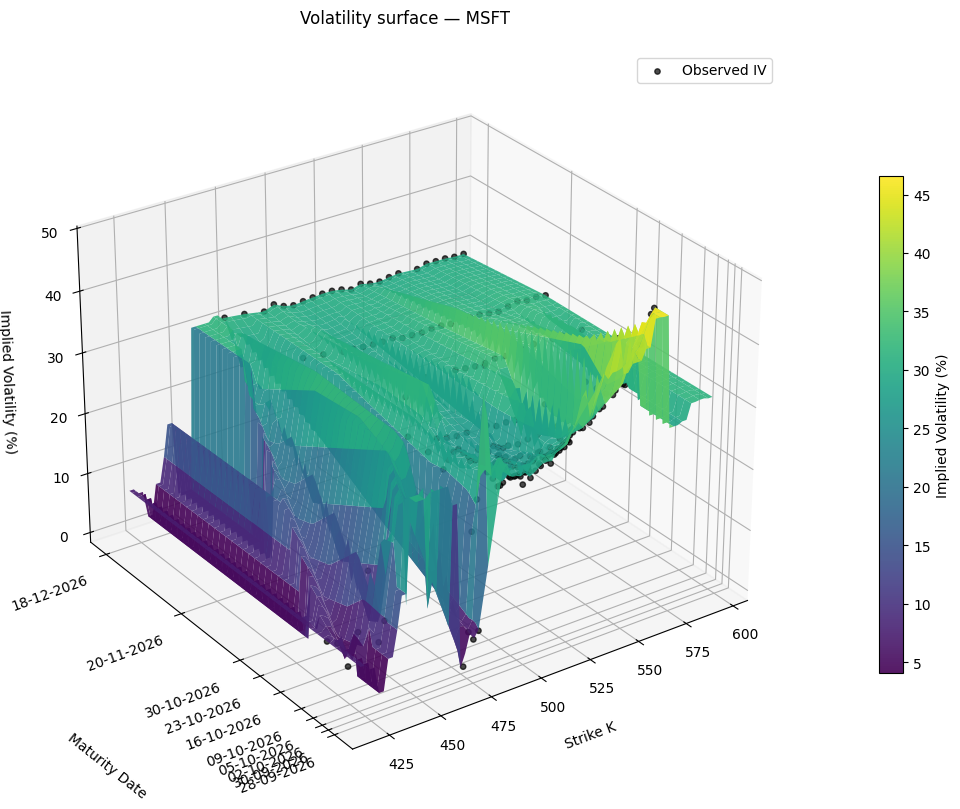

In [ ]:
# Ploting volatility surface 

valuation_date = pd.Timestamp.today().normalize()

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")


# Interpolated surface
surf = ax.plot_surface(
    K_mesh,                 # x : Strike
    T_mesh,                 # y : Maturity Date
    100 * IV_mesh_plot,     # z : IV in %
    cmap="viridis",
    edgecolor="none",
    alpha=0.90,
    antialiased=True
)


# Points of IV that are really observed
ax.scatter(
    K_obs,
    T_obs,
    100 * IV_obs,
    color="black",
    s=15,
    alpha=0.70,
    label="Observed IV"
)


# Labels x and z
ax.set_xlabel("Strike K $", labelpad=12)
ax.set_zlabel("Implied Volatility (%)", labelpad=12)



# Maturity date instead of time to maturity


maturity_dates = pd.to_datetime(
    sorted(df_call["Maturity"].unique())
)

T_ticks = (
    maturity_dates - valuation_date
).total_seconds() / (365.25 * 24 * 3600)

# Affiche environ 6 dates pour ne pas surcharger l'axe
step = max(1, len(maturity_dates) // 6)

ax.set_yticks(T_ticks[::step])

ax.set_yticklabels(
    maturity_dates[::step].strftime("%d-%m-%Y"),
    rotation=20,
    ha="right"
)

ax.set_ylabel("Maturity Date", labelpad=55)


ax.set_title(
    f"Volatility surface — {asset}",
    pad=20
)


# Initial view
ax.view_init(elev=28, azim=-125)


# Colorbar
fig.colorbar(
    surf,
    ax=ax,
    shrink=0.60,
    pad=0.10,
    label="Implied Volatility (%)"
)

ax.legend()

plt.tight_layout()
plt.show()